# Extracting condition-specific trials

The aim of this section is to extract the trials (epochs) corresponding to the experimental conditions, using the event labels derived from the trigger channels. In the spatial-attention (SpAtt) paradigm, a central cue instructs the participant to covertly attend to the left or right visual hemifield; we therefore segment the continuous recording into `cue_Left` and `cue_Right` trials.

Once the trials have been extracted, epochs contaminated by residual artefacts are identified and excluded on the basis of their peak-to-peak signal amplitude. The resulting cleaned, condition-labelled epochs are then saved to disk for the subsequent analyses (event-related fields, time–frequency power, decoding, and source reconstruction).

## Preparation
### Import the necessary modules
Below are the required Python modules to be imported


In [1]:
import os.path as op
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne_bids import BIDSPath, read_raw_bids


### File overview

This chapter relies on the following input files (embedded in the BIDS structure):

`<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ica_raw.fif`

the continuous data after ICA-based artefact suppression, and

`<BIDS_ROOT>/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ann.fif`

the artefact annotations marking segments (e.g. blinks, muscle activity) to be excluded during epoching.

It generates the output file

`<BIDS_ROOT>/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif`

which contains the condition-specific epochs.

Set the paths for the data and results below. Note that these will depend on your local setup.

In [2]:
subject = '01'
session = '01'
task    = 'SpAtt'
run     = '01'
meg_suffix = 'meg'
ica_suffix = 'ica_raw'   # input:  continuous data after ICA
epo_suffix = 'epo'       # output: condition-specific epochs

# Root folder holding the BIDS dataset. Adjust to your local setup.
#data_path = 'C:/Users/rakshita/Documents/Cerca_raw_files'
data_path = '/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data'
 

bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root_preproc  = op.join(bids_root, "derivatives/preprocessing")
deriv_root_analysis = op.join(bids_root, "derivatives/analysis")

# Path to the ICA-cleaned continuous data (input)
bids_path_preproc = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix=ica_suffix, datatype='meg',
            root=deriv_root_preproc, extension='.fif', check=False)

# Path to the epoched data (output); .mkdir() creates the target folder if needed
bids_path = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix=epo_suffix, datatype='meg',
            root=deriv_root_analysis, extension='.fif', check=False).mkdir()

deriv_fname = bids_path

print(bids_path_preproc.fpath)
print(deriv_fname)

/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ica_raw.fif
/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif



## Reading the events from the stimulus channels

First, read the continuous data produced in the previous chapter, in which artefacts were attenuated by ICA. At this stage we only need the annotations in order to derive the events, so the data are loaded lazily (`preload=False`):

In [3]:
# The sidecar .tsv/.json files live with the raw BIDS data, not in derivatives,
# so read_raw_bids warns that it cannot find them. The channel info and
# annotations are already stored in the .fif, so these warnings are harmless.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    raw = read_raw_bids(bids_path=bids_path_preproc,
                        extra_params={'preload': False}, verbose=True)

Opening raw data file /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ica_raw.fif...
    Read a total of 8 projection items:
        HFC: l=1 m=0 (1 x 170) active
        HFC: l=2 m=0 (1 x 170) active
        HFC: l=1 m=-1 (1 x 170) active
        HFC: l=1 m=1 (1 x 170) active
        HFC: l=2 m=-1 (1 x 170) active
        HFC: l=2 m=1 (1 x 170) active
        HFC: l=2 m=-2 (1 x 170) active
        HFC: l=2 m=2 (1 x 170) active
    Range : 0 ... 1241951 =      0.000 ...  1655.935 secs
Ready.


The following code will read the events according to annotations assigned with the BIDS formatting was done:

In [4]:
events, events_id = mne.events_from_annotations(raw,event_id='auto')

Used Annotations descriptions: [np.str_('blink'), np.str_('cue_Left'), np.str_('cue_Right'), np.str_('resp_L'), np.str_('resp_R'), np.str_('stimOnset')]


The annotations are represented in the array *events* where the first column is the sample and the third column the corresponding trigger value. The *events_id* is a dictionary of event names and trigger codes.

To visualise the *event_id*s and a snippet of the *events*-array write: 

In [5]:
events_id

{np.str_('blink'): 1,
 np.str_('cue_Left'): 2,
 np.str_('cue_Right'): 3,
 np.str_('resp_L'): 4,
 np.str_('resp_R'): 5,
 np.str_('stimOnset'): 6}

In [6]:
events[100:120]

array([[65461,     0,     1],
       [65811,     0,     2],
       [66754,     0,     6],
       [67992,     0,     1],
       [68084,     0,     5],
       [68534,     0,     1],
       [69018,     0,     3],
       [69962,     0,     6],
       [71848,     0,     1],
       [71978,     0,     5],
       [72304,     0,     1],
       [72612,     0,     3],
       [73574,     0,     6],
       [74844,     0,     1],
       [75170,     0,     1],
       [75281,     0,     4],
       [75667,     0,     1],
       [76344,     0,     2],
       [77281,     0,     6],
       [77778,     0,     1]])

To visualise the marked events along with the time course of the raw data in a browsing window, write:

In [7]:
%matplotlib qt
raw.plot(start=500);

Using qt as 2D backend.
Channels marked as bad:
none


## Defining the epochs (trials) according to the event values

We now extract the left- and right-cued trials, defined respectively by the `cue_Left` and `cue_Right` events. The data are reloaded with `preload=True` (the samples are required to cut the epochs), the events are regenerated, and a dictionary `events_picks_id` is built that keeps only the cue events — i.e. the annotations whose name starts with `cue`:

In [8]:
bids_path_preproc.update(run='01')

# Sidecar files are absent in derivatives (see note above); silence the harmless warnings.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    raw = read_raw_bids(bids_path=bids_path_preproc,
                        extra_params={'preload': True}, verbose=True)

events, events_id = mne.events_from_annotations(raw, event_id='auto')

# Keep only the cue events (cue_Left, cue_Right) that define the epochs
events_picks_id = {k: v for k, v in events_id.items() if k.startswith('cue')}

Opening raw data file /Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/preprocessing/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_ica_raw.fif...
    Read a total of 8 projection items:
        HFC: l=1 m=0 (1 x 170) active
        HFC: l=2 m=0 (1 x 170) active
        HFC: l=1 m=-1 (1 x 170) active
        HFC: l=1 m=1 (1 x 170) active
        HFC: l=2 m=-1 (1 x 170) active
        HFC: l=2 m=1 (1 x 170) active
        HFC: l=2 m=-2 (1 x 170) active
        HFC: l=2 m=2 (1 x 170) active
    Range : 0 ... 1241951 =      0.000 ...  1655.935 secs
Ready.
Reading 0 ... 1241951  =      0.000 ...  1655.935 secs...
Used Annotations descriptions: [np.str_('blink'), np.str_('cue_Left'), np.str_('cue_Right'), np.str_('resp_L'), np.str_('resp_R'), np.str_('stimOnset')]


As a check, print the picked ids:

In [9]:
print(events_picks_id)

{np.str_('cue_Left'): 2, np.str_('cue_Right'): 3}


Note that these numbers are not the acquisition trigger codes. Back in the DownsamplingBIDSconversion chapter the trigger word decoded to cue_Right = 2 and cue_Left = 4. Those numeric codes were turned into text labels (event_dict) and written into the BIDS events.tsv, which read_raw_bids loads as annotations. When events_from_annotations(..., 'auto') then converts those text labels back into an integer event array, it re-numbers them 1…10 alphabetically — which is how cue_Left/cue_Right end up as 5/6 rather than 4/2. So the 5 and 6 are just alphabetical bookkeeping, meaningful only within this notebook's events_id.

Set the peak-to-peak amplitude threshold for trial rejection. This is an additional safeguard ensuring that epochs containing excessive residual artefacts are discarded: any epoch in which a magnetometer spans more than the threshold (here `1e-11` T, i.e. 10 pT peak-to-peak) is dropped. Ideally such segments are already flagged as annotations in the Artefact Annotation chapter, in which case this threshold acts as a backstop. The value may need adjusting depending on the quality of the data.

In [10]:
reject = dict(mag=1e-11)   # drop epochs with >10 pT peak-to-peak in any magnetometer

**Question 1** The rejection threshold of 10 pT was chosen by inspection. Propose an objective, data-driven way to set this threshold rather than by trial and error, and discuss the trade-off between a strict and a lenient value in terms of trial count and possible bias.

The time window of interest is −0.75 to 2 s relative to cue onset, capturing the pre-cue baseline together with the anticipatory attention interval that follows the cue. The epochs are now cut with the following settings:

- `baseline=None` — no baseline correction is applied at this stage (it can be applied later, tailored to each analysis).
- `detrend=1` — a linear trend is removed from every epoch.
- `picks='all'` — all channels are retained.
- `reject` together with `reject_by_annotation=True` — epochs are dropped based on the amplitude threshold defined above and on the artefact annotations carried by the data.

In [11]:
epochs = mne.Epochs(raw,
            events, events_picks_id,
            tmin=-0.75, tmax=2,
            baseline=None,
            proj=False,
            picks='all',
            detrend=1,
            reject=reject,
            reject_by_annotation=True,
            preload=True,
            verbose=False)

**Question 2** The epochs span −0.75 to 2 s around cue onset. What considerations determine a sensible pre-cue and post-cue interval here, and what would you lose (or gain) by shortening `tmin` to −0.2 s?

**Question 3** Here a per-epoch linear detrend is applied (`detrend=1`). What does a linear detrend do, and how might it compare to applying a high-pass filter?

To display the details of the epochs write

In [12]:
epochs

<Epochs | 295 events (all good), -0.749 – 2 s (baseline off), ~795.7 MiB, data loaded,
 np.str_('cue_Left'): 144
 np.str_('cue_Right'): 151>

Note that there are 144 cue-left trials and 151 cue-right trials.

Now plot an overview of the rejected epochs:


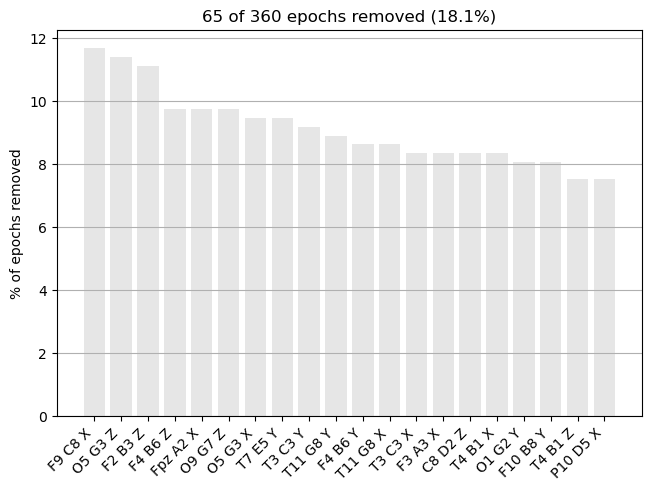

In [13]:
%matplotlib inline
epochs.plot_drop_log();



A percentage of the trials were rejected due to artefacts in the magnetometers.

Now we save the epoched data in an FIF-file. 



In [14]:
print(deriv_fname)

/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif


In [15]:
epochs.save(deriv_fname, overwrite=True)

[PosixPath('/Users/o.jensen@bham.ac.uk/Data/CercaOxf/subjB/Data/Cerca_Spatt_BIDS/derivatives/analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif')]


## Plotting the trials

To show the trials for the left cue condition for the OPM sensors:

In [16]:
%matplotlib qt
OPMZ = [item for item in epochs.ch_names if item.endswith("Z") and not item.startswith("BNC")]
epochs['cue_Left'].plot(picks=OPMZ);

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


The plot above shows the trials cued to the left. 

To show all the trials belonging to left for a representative OPM Sensor (O6 H1 Z) use the plot_image function. In the following example we also lowpass filter the indvidual trials at 30 Hz and shorten them (crop) to a -100 to 400 ms interval:


Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 24751 samples (33.001 s)



/var/folders/n0/w7vb4jpn0nx3hs95f4p7r9br0000gr/T/ipykernel_56331/35903505.py:2: RuntimeWarning: filter_length (24751) is longer than the signal (2063), distortion is likely. Reduce filter length or filter a longer signal.
  epochs['cue_Left'].filter(0.1,30).crop(-0.1,0.4).apply_baseline(baseline=(-0.1, 0)).plot_image(picks=['O2 H7 Z'], vmin=-2500, vmax=2500);


Applying baseline correction (mode: mean)
Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated


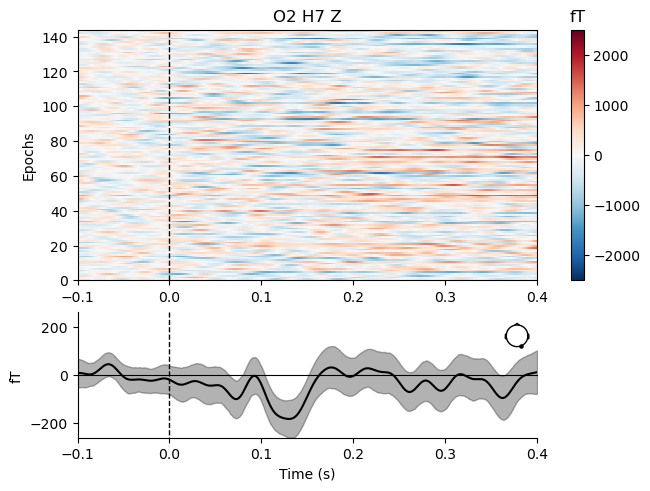

In [18]:
%matplotlib inline
epochs['cue_Left'].filter(0.1,30).crop(-0.1,0.4).apply_baseline(baseline=(-0.1, 0)).plot_image(picks=['O2 H7 Z'], vmin=-2500, vmax=2500);

**Question 4** For visualisation the epochs are filtered (0.1–30 Hz), cropped, and baseline-corrected, yet the *saved* epochs are left broadband and un-baselined. Why is it good practice to store the data in this minimally processed form and defer such steps to the plotting/analysis stage?

## Preregistration and Publication

A preregistration should specify the epoching and trial-rejection pipeline in enough detail to be reproduced exactly. Because the rejection criteria determine how many trials survive — and therefore the statistical power — these choices should be fixed in advance rather than tuned to the result. We recommend committing to the following:

**Epoch definition**
- The events used to time-lock the epochs (here `cue_Left` and `cue_Right`) and how they are obtained (annotations derived from the trigger channels).
- The epoch window relative to the locking event (here −0.75 to 2 s) and the rationale for it (pre-cue baseline plus the anticipatory attention interval).
- Whether and how detrending and baseline correction are applied (here a per-epoch linear detrend, with `baseline=None`).

**Trial rejection**
- The peak-to-peak amplitude threshold and the channel type it applies to (here 10 pT on the magnetometers).
- Any annotation-based rejection applied in addition (`reject_by_annotation=True`, covering the previously marked blink and muscle segments).
- The expected proportion of trials rejected per participant, and any rule for excluding a participant or run that retains too few trials or an unbalanced number of trials across conditions.

**General**
- Software and versions (MNE-Python, MNE-BIDS).
- Where the epoched data are stored (`*_epo.fif` under BIDS `derivatives/analysis`).

**Example preregistration / methods text**

> "Epochs were extracted from the ICA-cleaned continuous data from −0.75 to 2 s around the onset of the left and right attention cues. A linear detrend was applied to each epoch to attenuate slow drifts, and no baseline correction was performed at this stage. Epochs were rejected if the peak-to-peak amplitude of any magnetometer exceeded 10 pT, or if they overlapped a segment previously annotated as an eye-blink or muscle artefact. This yielded on average XXX left-cue and XXX right-cue trials per participant (mean rejection rate XX%)."

## References

[1] Gramfort, A., Luessi, M., Larson, E., et al. (2013). MEG and EEG data analysis with MNE-Python. *Frontiers in Neuroscience*, **7**, 267. [https://doi.org/10.3389/fnins.2013.00267](https://doi.org/10.3389/fnins.2013.00267)

[2] Appelhoff, S., Sanderson, M., Brooks, T. L., et al. (2019). MNE-BIDS: Organizing electrophysiological data into the BIDS format and facilitating their analysis. *Journal of Open Source Software*, **4**(44), 1896. [https://doi.org/10.21105/joss.01896](https://doi.org/10.21105/joss.01896)